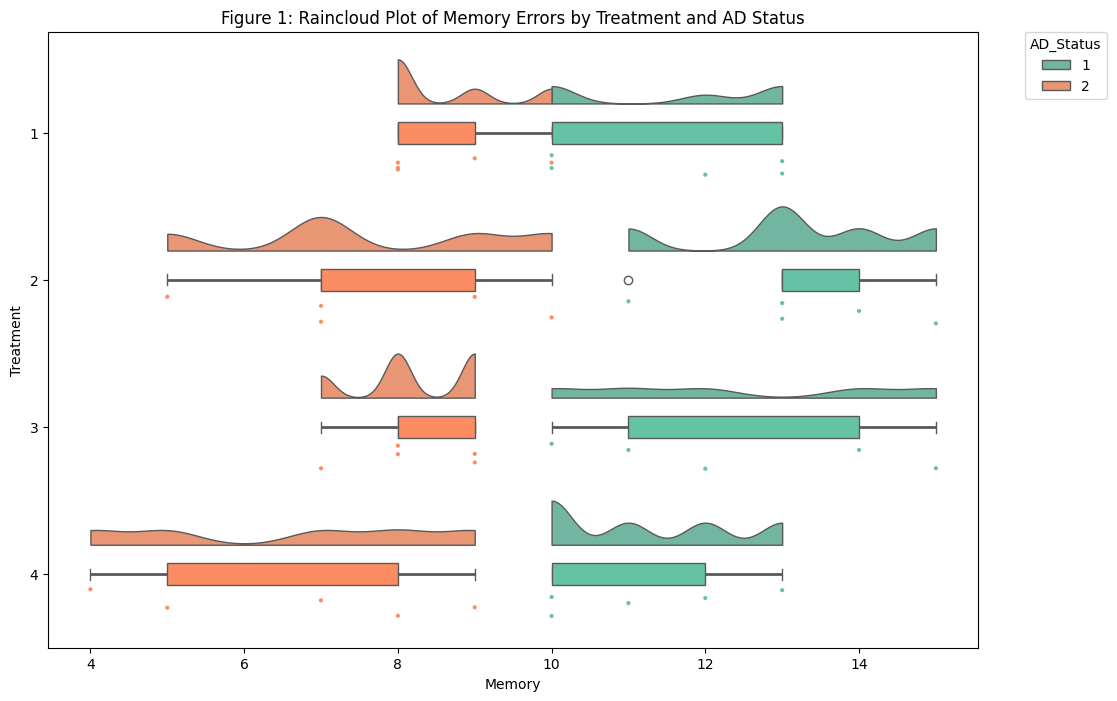

--- Normality Test per Group (Memory) ---
                                W      pval  normal
AD_Status Treatment                                
1         1         1 1  0.802990  0.085693    True
          2         1 2  0.955627  0.777253    True
          3         1 3  0.952351  0.753973    True
          4         1 4  0.902020  0.421150    True
2         1         2 1  0.770908  0.045954   False
          2         2 2  0.952960  0.758312    True
          3         2 3  0.881038  0.314040    True
          4         2 4  0.952351  0.753973    True


--- Test of Homogeneity of Variances (Levene's) ---
               W     pval  equal_var
levene  0.827458  0.57222       True
--- Memory Day Analysis ---
                  Source       SS  DF        MS        F   p_unc     np2
0              AD_Status  189.225   1  189.2250  75.3134  0.0000  0.7018
1              Treatment   14.475   3    4.8250   1.9204  0.1461  0.1526
2  AD_Status * Treatment    8.675   3    2.8917   1.1509  0.343

In [9]:
!pip install pingouin statsmodels ptitprince -q

import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import ptitprince as pt

# Load data
df = pd.read_csv('Alzheimers Mice Data.csv')

#Assumption #4: No Significant Outliers
plt.figure(figsize=(12, 8))
ax = pt.RainCloud(x='Treatment', y='Memory', hue='AD_Status', data=df,
                  palette='Set2', bw=0.2, width_viol=0.6, orient='h', move=0.2)
plt.title('Figure 1: Raincloud Plot of Memory Errors by Treatment and AD Status')
plt.show()

#Assumption #5: Normality
print("--- Normality Test per Group (Memory) ---")
norm_test = df.groupby(['AD_Status', 'Treatment'])['Memory'].apply(pg.normality)
print(norm_test)
print("\n")

#Assumption #6 and #7): Homogeneity of Variances
df['Combination'] = df['AD_Status'].astype(str) + "_" + df['Treatment'].astype(str)
print("--- Test of Homogeneity of Variances (Levene's) ---")
levene_res = pg.homoscedasticity(data=df, dv='Memory', group='Combination')
print(levene_res)

# ANOVA for Memory
print("--- Memory Day Analysis ---")
anova_mem = pg.anova(data=df, dv='Memory', between=['AD_Status', 'Treatment'], detailed=True)
print(anova_mem.round(4))

#ANOVA for Training
print("\n--- Training Day Analysis ---")
anova_train = pg.anova(data=df, dv='Training', between=['AD_Status', 'Treatment'], detailed=True)
print(anova_train.round(4))

#Post-hoc for Training
posthoc = pg.pairwise_tests(data=df, dv='Training', between='Treatment', padjust='bonf')
print("\n--- Training Post-hoc ---")
print(posthoc[['A', 'B', 'p_unc', 'p_corr']].round(4))